In [ ]:
%matplotlib inline

from pathlib import Path

import numpy as np

from engine.utils import display_matrix, mask_image_to_segment_arrays
from ml.utils.utils import get_project_root

from skimage.draw import line
from skimage.morphology import skeletonize, dilation, disk, remove_small_objects
from skimage.measure import label, regionprops
from scipy.ndimage import convolve, distance_transform_edt

In [550]:
mask_path = (
    get_project_root()
    / "datasets/segmentation/crack_segmentation_dataset/train/masks/CFD_031.jpg"
)
masks = mask_image_to_segment_arrays(mask_path)

combined_masks = [
    np.logical_or(mask1, mask2).astype(np.uint8)
    for mask1, mask2 in zip(masks[:-1], masks[1:])
]

labels = [label(mask) for mask in combined_masks]

print(f"{len(masks)} segments, {len(combined_masks)} combined pairs")

if labels:
    display_matrix(
        labels,
        titles=[f"Combined pair {i + 1}" for i in range(len(labels))],
        cmap="nipy_spectral",
        suptitle=mask_path.name,
    )
else:
    print("No combined pairs to display (need 2+ segments). Run cell 2 for skeleton analysis.")


1 segments, 0 combined pairs
No combined pairs to display (need 2+ segments). Run cell 2 for skeleton analysis.


number of branches: 27


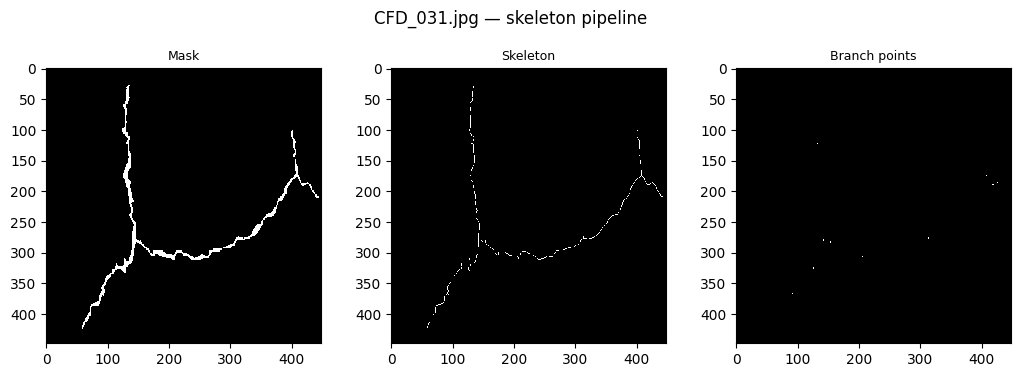

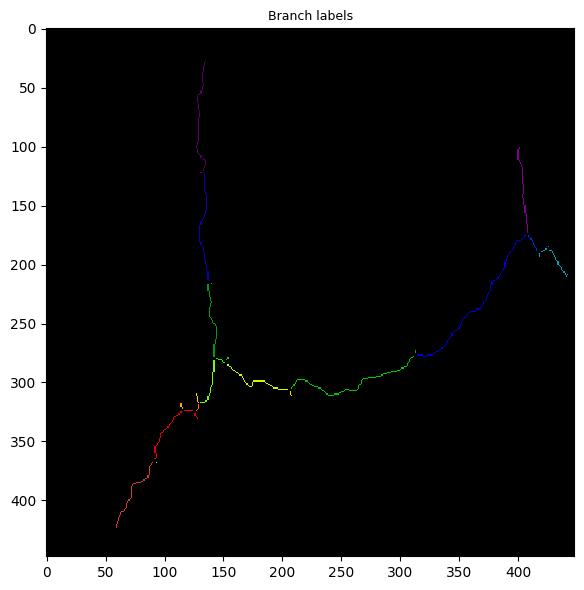

In [569]:
from scipy.ndimage import convolve
from skimage.measure import label
from skimage.morphology import skeletonize

if not masks:
    raise ValueError(f"No segments found in {mask_path}")

crack_mask = masks[0]

# 1. Skeletonize
skel = skeletonize(crack_mask > 0)

# 2. Count 8-neighbors for each skeleton pixel
kernel = np.array([
    [1, 1, 1],
    [1, 0, 1],
    [1, 1, 1],
])

neighbor_count = convolve(skel.astype(np.uint8), kernel, mode="constant", cval=0)

# 3. Branch points are skeleton pixels with 3+ neighbors
branch_points = skel & (neighbor_count >= 3)

# 4. Remove branch points
skel_no_branches = skel.copy()
skel_no_branches[branch_points] = False

# 5. Label the remaining disconnected branches
branches = label(skel_no_branches, connectivity=2)

print("number of branches:", branches.max())

display_matrix(
    [crack_mask, skel.astype(np.uint8), branch_points.astype(np.uint8)],
    titles=["Mask", "Skeleton", "Branch points"],
    cmap="gray",
    suptitle=f"{mask_path.name} — skeleton pipeline",
)

display_matrix(
    branches,
    title="Branch labels",
    cmap="nipy_spectral",
)

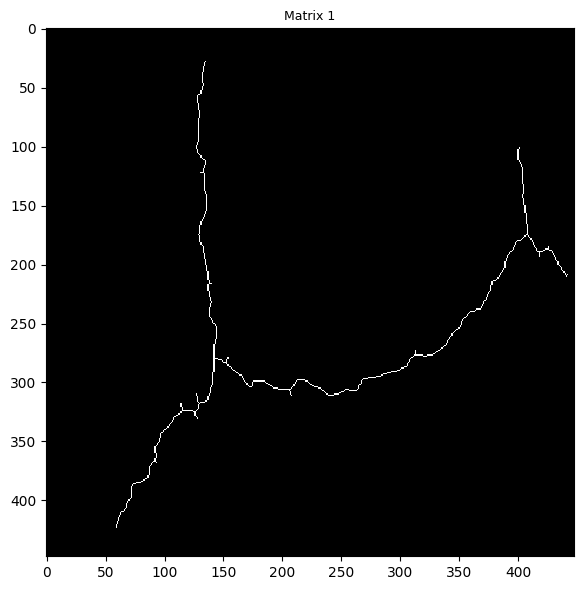

11


In [552]:
branches = []
        

mask = crack_mask
skeleton = skeletonize(mask)

kernel_4 = np.array([
    [0, 1, 0],
    [1, 0, 1],
    [0, 1, 0],
])

kernel_8 = np.array([
    [1, 1, 1],
    [1, 0, 1],
    [1, 1, 1],
])

display_matrix(skeleton, cmap="gray")

neighbors_8 = convolve(skeleton.astype(np.uint8), kernel_8, mode="constant", cval=0)
neighbors_4 = convolve(skeleton.astype(np.uint8), kernel_4, mode="constant", cval=0)

# Branch points are skeleton pixels with 3+ neighbors
branch_points_8 = skeleton & (neighbors_8 >= 3)
branch_points_4 = skeleton & (neighbors_4 >= 3)

branch_points = branch_points_8
# Junction zone is the area around the branch points to remove them from the skeleton
junction_zone = dilation(branch_points, disk(5))

skel_no_branches = skeleton.copy()
# Remove the junction zone from the skeleton
skel_no_branches[junction_zone] = False

# Label the branches
labels = label(skel_no_branches, connectivity=2)

# Convert the labels to region properties
prepruned_branches = sorted(regionprops(labels), key=lambda r: r.area, reverse=True)

# Output is a mask of the branches


for branch in prepruned_branches:
    branch_mask = np.zeros_like(labels)
    
    area = branch.area
    
    branch_mask[labels == branch.label] = 1
    
    
    if branch.area > 10:
        branches.append(branch_mask)
    
print(len(branches))

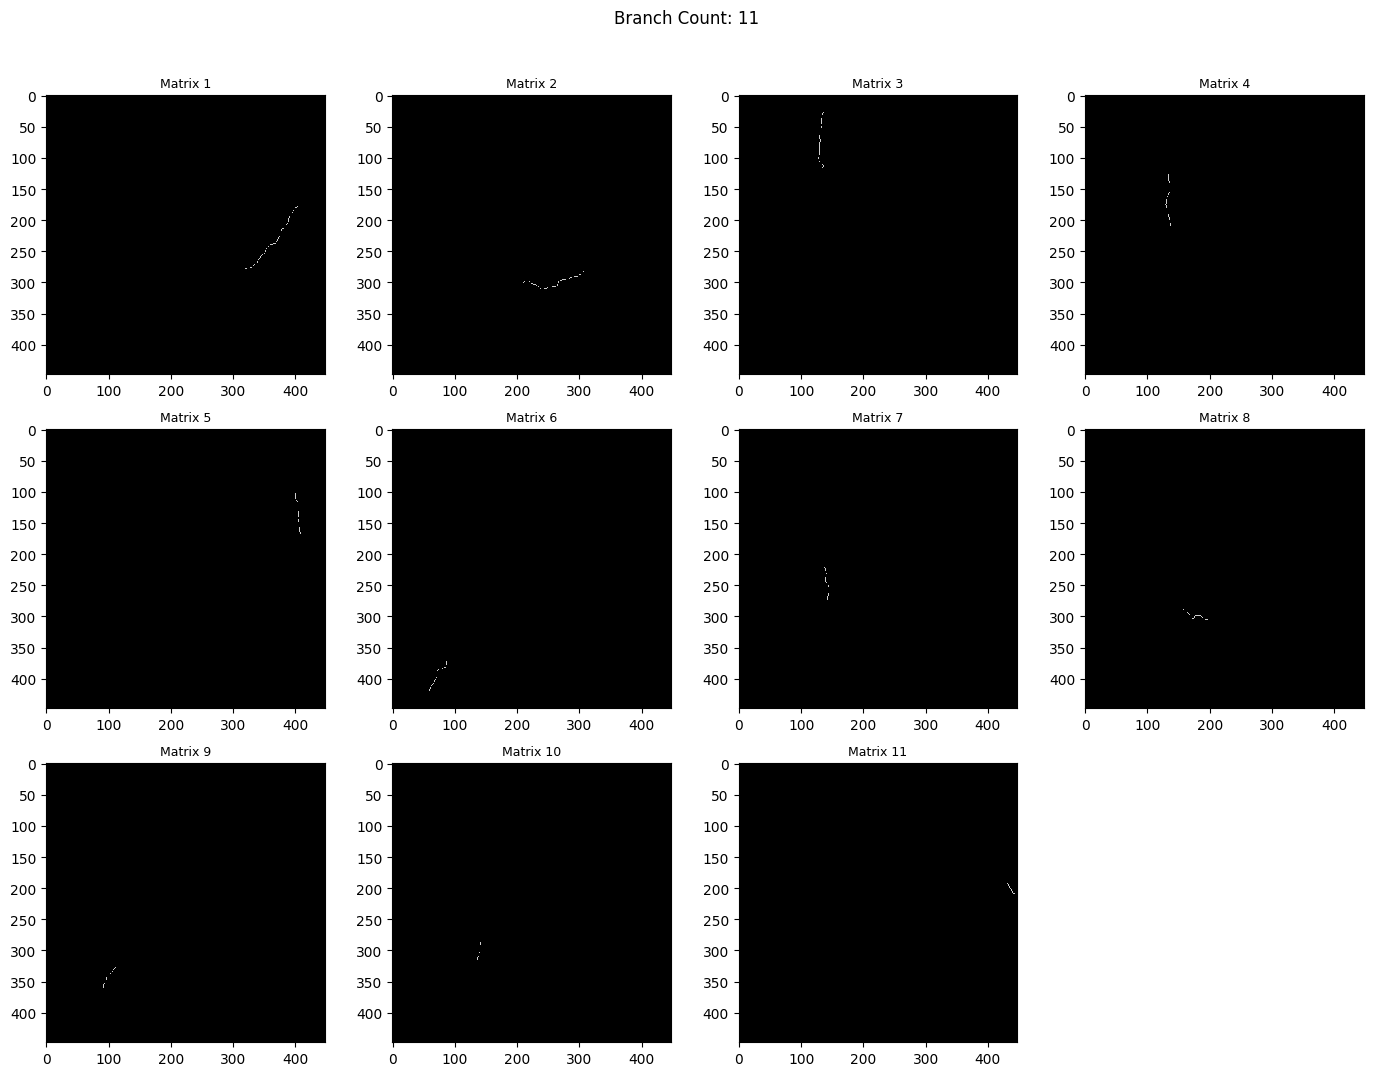

In [553]:
display_matrix(branches, title="Branches", cmap="nipy_spectral", suptitle=f"Branch Count: {len(branches)}")

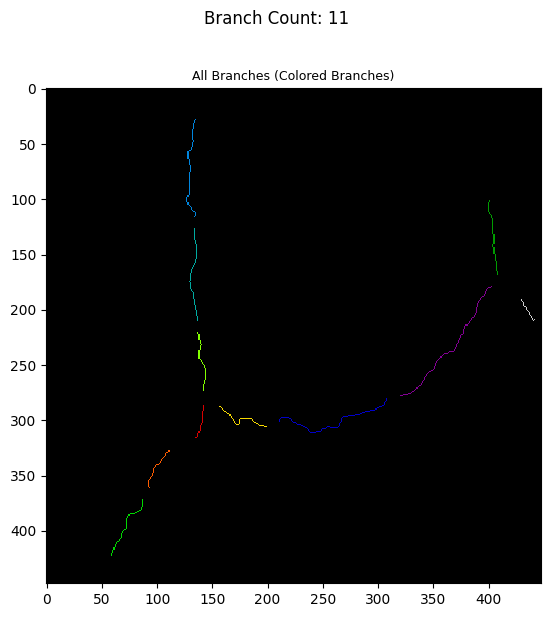

In [554]:
# Assign each branch mask a unique label so each gets its own color
colored_branches = np.zeros(labels.shape, dtype=np.int32)

for index, branch in enumerate(branches, start=1):
    
    colored_branches[branch > 0] = index

display_matrix(
    colored_branches,
    title="All Branches (Colored Branches)",
    cmap="nipy_spectral",
    suptitle=f"Branch Count: {len(branches)}",
)

In [555]:
def _get_endpoints(mask: np.ndarray) -> np.ndarray:
    # Thin the mask to get pixels
    skeleton_mask = skeletonize(mask)

    # Use scipy to convolve the mask with a 3x3 kernel. To count neighbors of a pixel.
    kernel_8 = np.array(
        [
            [1, 1, 1],
            [1, 0, 1],
            [1, 1, 1],
        ]
    )

    kernel_4 = np.array(
        [
            [0, 1, 0],
            [1, 0, 1],
            [0, 1, 0],
        ]
    )

    # Convolve the mask with the kernel to count neighbors of a pixel.
    convolved_8 = convolve(
        skeleton_mask.astype(np.uint8), kernel_8, mode="constant", cval=0
    )

    # Get the endpoints of the mask.
    endpoints_8 = np.argwhere(skeleton_mask & (convolved_8 == 1))

    if len(endpoints_8) >= 2:
        endpoints = endpoints_8
    else:
        # Use the 4-connected kernel to get the endpoints.
        convolved_4 = convolve(
            skeleton_mask.astype(np.uint8), kernel_4, mode="constant", cval=0
        )
        endpoints = np.argwhere(skeleton_mask & (convolved_4 == 1))

    return endpoints

Branch 0: 50.0°
Branch 0: 123.7°, 303.7°
Branch 1: 11.7°
Branch 1: 123.7°, 303.7°
Branch 2: 89.3°
Branch 2: 123.7°, 303.7°
Branch 3: 92.1°
Branch 3: 123.7°, 303.7°
Branch 4: 96.0°
Branch 4: 123.7°, 303.7°
Branch 5: 61.2°
Branch 5: 123.7°, 303.7°
Branch 6: 95.5°
Branch 6: 123.7°, 303.7°
Branch 7: 156.8°
Branch 7: 123.7°, 303.7°
Branch 8: 61.4°
Branch 8: 123.7°, 303.7°
Branch 9: 76.4°
Branch 9: 123.7°, 303.7°
Branch 10: 123.7°
Branch 10: 123.7°, 303.7°


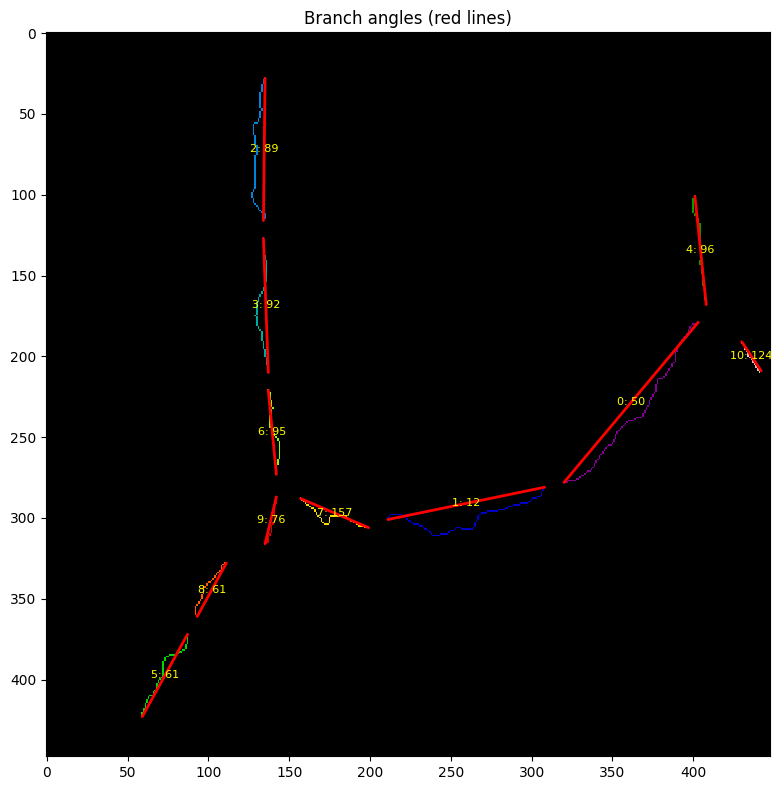

In [ ]:
import matplotlib.pyplot as plt

def _farthest_endpoint_pair(endpoints: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    if len(endpoints) < 2:
        raise ValueError("Need at least 2 endpoints")
    if len(endpoints) == 2:
        return endpoints[0], endpoints[1]

    diffs = endpoints[:, None, :] - endpoints[None, :, :]
    distances = np.linalg.norm(diffs, axis=2)
    i, j = np.unravel_index(np.argmax(distances), distances.shape)
    return endpoints[i], endpoints[j]


fig, axis = plt.subplots(figsize=(8, 8))
axis.imshow(colored_branches, cmap="nipy_spectral", interpolation="nearest")

branch_objects = {}

for index, branch in enumerate(branches):    
    endpoints = _get_endpoints(branch)
    if len(endpoints) < 2:
        print(f"Branch {index}: skipped (fewer than 2 endpoints)")
        continue

    ep0, ep1 = _farthest_endpoint_pair(endpoints)
    row0, col0 = ep0
    row1, col1 = ep1

    angle = np.degrees(np.arctan2(row1 - row0, col0 - col1)) % 360
    
    print(f"Branch {index}: {angle:.1f}°")
    
    branch_objects[index] = {
        "index": index,
        "branch": branch,
        "endpoints": endpoints,
        "angle": angle,
        "row0": row0,
        "col0": col0,
        "row1": row1,
        "col1": col1
    }
    # Line along the branch axis (image coords: x=col, y=row)
    axis.plot(
        [col0, col1],
        [row0, row1],
        color="red",
        linewidth=2,
        solid_capstyle="round",
    )
    mid_row, mid_col = (row0 + row1) / 2, (col0 + col1) / 2
    axis.text(
        mid_col,
        mid_row,
        f"{index}: {angle:.0f}",
        color="yellow",
        fontsize=8,
        ha="center",
        va="center",
    )
    print(f"Branch {index}: {angle:.1f}°")

axis.set_title("Branch angles (red lines)")
axis.set_aspect("equal")
plt.tight_layout()
plt.show()

In [ ]:
def angle_difference_180(a: float, b: float) -> float:
    # Lines are undirected, so 10° and 190° are equivalent.
    return abs((a - b + 90) % 180 - 90)


def branch_axis_angle(mask: np.ndarray) -> float:
    endpoints = _get_endpoints(mask)

    if len(endpoints) < 2:
        pixels = np.argwhere(mask > 0)
        if len(pixels) < 2:
            return 0.0
        ep0, ep1 = _farthest_endpoint_pair(pixels)
    else:
        ep0, ep1 = _farthest_endpoint_pair(endpoints)

    row0, col0 = ep0
    row1, col1 = ep1

    angle = np.degrees(np.arctan2(row1 - row0, col1 - col0)) % 180
    return angle


def local_endpoint_angle(mask: np.ndarray, endpoint: np.ndarray, radius: int = 25) -> float:
    skeleton = skeletonize(mask > 0)
    points = np.argwhere(skeleton)

    if len(points) < 2:
        return 0.0

    distances = np.linalg.norm(points - endpoint, axis=1)
    local_points = points[distances <= radius]

    if len(local_points) < 2:
        local_points = points[np.argsort(distances)[: min(10, len(points))]]

    # Use PCA to estimate local direction.
    centered = local_points - local_points.mean(axis=0)
    _, _, vh = np.linalg.svd(centered, full_matrices=False)

    d_row, d_col = vh[0]
    angle = np.degrees(np.arctan2(d_row, d_col)) % 180

    return angle

def make_branch_object(mask: np.ndarray) -> dict:
    return {
        "branch": mask,
        "endpoints": _get_endpoints(mask),
        "angle": branch_axis_angle(mask),
    }
    
def angle_between_points(p1: np.ndarray, p2: np.ndarray) -> float:
    row1, col1 = p1
    row2, col2 = p2
    return np.degrees(np.arctan2(row2 - row1, col2 - col1)) % 180


def can_combine(
    branch1: dict,
    branch2: dict,
    distance_threshold: int = 50,
    angle_threshold: int = 45,
):
    ep1, ep2, distance = get_closest_endpoint_pair(
        branch1["endpoints"],
        branch2["endpoints"],
    )

    if distance >= distance_threshold:
        return False, ep1, ep2, np.inf

    angle1 = local_endpoint_angle(branch1["branch"], ep1)
    angle2 = local_endpoint_angle(branch2["branch"], ep2)

    angle_diff = angle_difference_180(angle1, angle2)

    if angle_diff >= angle_threshold:
        return False, ep1, ep2, np.inf

    score = distance + angle_diff
    return True, ep1, ep2, score

In [564]:
def get_closest_endpoint_pair(endpoints1: np.ndarray, endpoints2: np.ndarray):
    if len(endpoints1) == 0 or len(endpoints2) == 0:
        return np.array([]), np.array([]), np.inf

    diffs = endpoints1[:, None, :] - endpoints2[None, :, :]
    distances = np.linalg.norm(diffs, axis=2)

    i, j = np.unravel_index(np.argmin(distances), distances.shape)

    return endpoints1[i], endpoints2[j], distances[i, j]

def connect_endpoints(
        mask1: np.ndarray,
        mask2: np.ndarray,
        endpoint1: np.ndarray,
        endpoint2: np.ndarray,
    ) -> np.ndarray:
    combined_mask = np.logical_or(mask1, mask2).astype(np.uint8)

    # Update line to use binary dialation to have a realistic radius.

    rr, cc = line(
        int(endpoint1[0]),
        int(endpoint1[1]),
        int(endpoint2[0]),
        int(endpoint2[1]),
    )

    combined_mask[rr, cc] = 1

    return combined_mask

In [565]:
def combine_branches(
    branch_objects: dict,
    distance_threshold: int = 45,
    angle_threshold: int = 30,
) -> list[np.ndarray]:
    branch_objects = dict(branch_objects)
    next_id = max(branch_objects.keys(), default=-1) + 1

    while True:
        best_pair = None
        best_endpoints = None
        best_score = np.inf

        keys = list(branch_objects.keys())

        for idx, i in enumerate(keys):
            for j in keys[idx + 1:]:
                ok, ep_i, ep_j, score = can_combine(
                    branch_objects[i],
                    branch_objects[j],
                    distance_threshold=distance_threshold,
                    angle_threshold=angle_threshold,
                )
                if {i, j} == {1, 2}:
                    print("1-2 debug")
                    print("distance:", np.linalg.norm(ep_i - ep_j) if ep_i is not None else None)
                    print("angle 1:", branch_objects[i]["angle"])
                    print("angle 2:", branch_objects[j]["angle"])
                    print("angle diff:", angle_difference_180(
                        branch_objects[i]["angle"],
                        branch_objects[j]["angle"],
                    ))
                    print("ok:", ok)

                if ok and score < best_score:
                    best_pair = (i, j)
                    best_endpoints = (ep_i, ep_j)
                    best_score = score

        if best_pair is None:
            break

        i, j = best_pair
        ep_i, ep_j = best_endpoints

        merged_branch = connect_endpoints(
            branch_objects[i]["branch"],
            branch_objects[j]["branch"],
            ep_i,
            ep_j,
        )

        branch_objects.pop(i)
        branch_objects.pop(j)

        branch_objects[next_id] = make_branch_object(merged_branch)
        next_id += 1

    return [obj["branch"] for obj in branch_objects.values()]

In [566]:
# Test Helper
combined_results = combine_branches(branch_objects)

1-2 debug
distance: 200.38463014912097
angle 1: 11.650299437537667
angle 2: 89.3489396197705
angle diff: 77.69864018223284
ok: False


In [567]:
import matplotlib.pyplot as plt

def display_combined_results(combined_results: list[np.ndarray]):
    if not combined_results:
        print("No combined results to display")
    else:
        # Colorize each combined result with a unique label and overlay on one image
        colored_combined = np.zeros_like(combined_results[0], dtype=np.int32)

        for index, mask in enumerate(combined_results, start=1):
            colored_combined[mask > 0] = index

        fig, axis = plt.subplots(figsize=(8, 8))
        axis.imshow(colored_combined, cmap="nipy_spectral", interpolation="nearest")

        for index, mask in enumerate(combined_results, start=1):
            rows, cols = np.where(mask > 0)
            if rows.size == 0:
                continue
            axis.text(
                cols.mean(),
                rows.mean(),
                str(index),
                color="white",
                fontsize=11,
                fontweight="bold",
                ha="center",
                va="center",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.7),
            )

        axis.set_title("Combined Results")
        axis.set_aspect("equal")
        fig.suptitle(f"Branch count: {len(combined_results)}", fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()

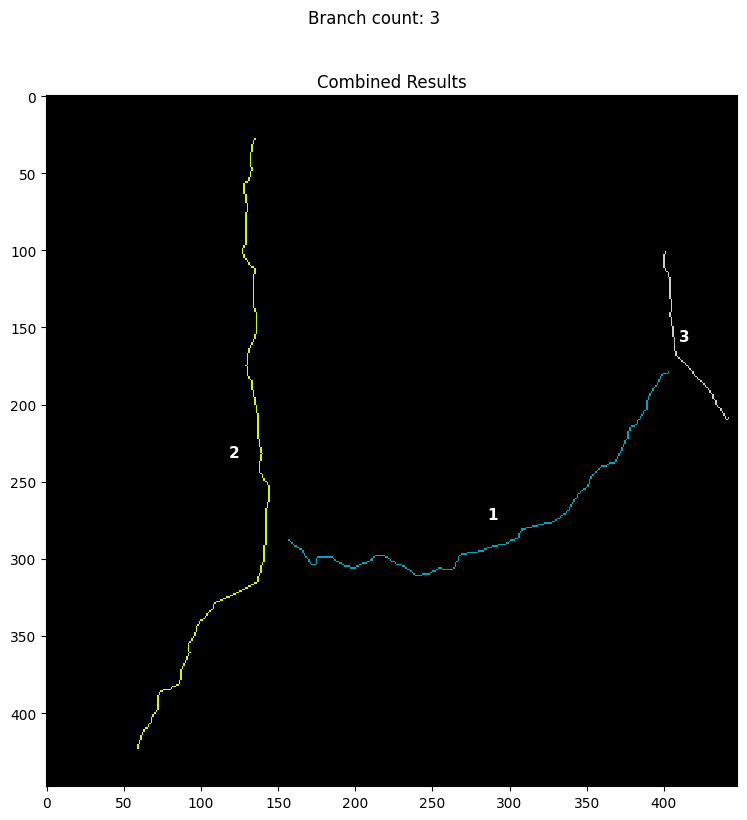

In [568]:
display_combined_results(combined_results)